In [2]:
scenic = pd.read_csv('../../scenic_plus_testing/scenic_plus_guang/eRegulon_direct_guang.tsv', delimiter = '\t')

In [3]:
otohomo = pd.read_csv('../../OTO_star_nothreshold_missing_le2_expressionthresh_08022026.tsv',delimiter='\t',index_col = 'MM')

In [4]:
orthogroups = pd.read_csv('../../Vert_emapper_allorgs_08012026.tsv', delimiter = '\t',index_col = 'Unnamed: 0')

In [17]:
def orthogroup_mapper(orthogroups, label):
    mapping = {}
    for index in orthogroups.index:
        gene_list = orthogroups.loc[index, label]
        if type(gene_list) != float:
            genes = gene_list.split(',')
            for item in genes:
                mapping[item] = index
    return(mapping)

In [18]:
mm_mapping_ortho = orthogroup_mapper(orthogroups,'MM')
mo_mapping_ortho = orthogroup_mapper(orthogroups,'MO')
cj_mapping_ortho = orthogroup_mapper(orthogroups,'CJ')
ac_mapping_ortho = orthogroup_mapper(orthogroups,'AC')
xt_mapping_ortho = orthogroup_mapper(orthogroups,'XT')
dr_mapping_ortho = orthogroup_mapper(orthogroups,'DR')

In [19]:
!pip install anndata==0.8.0

In [20]:
!pip install openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.3/251.3 kB 4.4 MB/s eta 0:00:0000:01


In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from sklearn.neighbors import KernelDensity
import time
import dill
import pickle
from scipy.spatial import distance
import os
import scipy
from tqdm import tqdm
import matplotlib as mpl

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
sam_mg = SAM()
sam_mg.load_data('../../Active_SAM_joined/SAM_Allen_Institute_allhypo_01272026.h5ad')
gene_dict_mg = {}
for i in range(len(sam_mg.adata.var_names)):
    gene_dict_mg[sam_mg.adata.var_names[i]] = i

In [8]:
sam_mo = SAM()
sam_mo.load_data('../../Active_SAM_joined/SAM_MO_soupx_plus5_cleaned_NN_04142026.h5ad')
gene_dict_mo = {}
for i in range(len(sam_mo.adata.var_names)):
    gene_dict_mo[sam_mo.adata.var_names[i]] = i

In [9]:
sam_cj = SAM()
sam_cj.load_data('../../Active_SAM_joined/SAM_CJ_joined_v2_cleaned_03122025.h5ad')
gene_dict_cj = {}
for i in range(len(sam_cj.adata.var_names)):
    gene_dict_cj[sam_cj.adata.var_names[i]] = i

In [10]:
sam_ac= SAM()
sam_ac.load_data('../../Active_SAM_joined/SAM_AC_ncbi_soupx_cleaned_03122025.h5ad')
gene_dict_ac = {}
for i in range(len(sam_ac.adata.var_names)):
    gene_dict_ac[sam_ac.adata.var_names[i]] = i

In [11]:
sam_xt = SAM()
sam_xt.load_data('../../Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_03122205.h5ad')
gene_dict_xt = {}
for i in range(len(sam_xt.adata.var_names)):
    gene_dict_xt[sam_xt.adata.var_names[i]] = i

In [12]:
sam_dr = SAM()
sam_dr.load_data('../../Active_SAM_joined/SAM_DR_ncbi_joined_cleaned_07172026.h5ad')
gene_dict_dr = {}
for i in range(len(sam_dr.adata.var_names)):
    gene_dict_dr[sam_dr.adata.var_names[i]] = i

In [5]:
TF = pd.read_csv('../../Fin_TF_06012026.csv')
TF = TF.rename(columns={'0': 0})
TF_set = set(TF[0]) & set(otohomo.index)
neuropep = pd.read_csv('../../Neuropeptides_receptors_10202025.csv')
neuropep_list = list(neuropep['Neuropeptide names'].unique())

In [6]:
len(TF_set)

858

In [26]:
exp = sam_mg.adata.X.A
all_exp_ct = np.zeros((sam_mg.adata.obs['subclass_id_label'].nunique(),len(sam_mg.adata.var_names)))
ctl = sam_mg.adata.obs['subclass_id_label'].unique()
for i in range(len(ctl)):
    all_exp_ct[i,:] = np.average(exp[sam_mg.adata.obs['subclass_id_label'] == ctl[i],:], axis = 0)

In [27]:
scenic_np_tf = []
mg_vals = []
for g in neuropep_list:
    scg = list(scenic['Gene'])
    if g in scg:
        if len(set(scenic[scenic['Gene'] == g]['TF'])& TF_set) > 0 and g in otohomo.index:
            for item in set(scenic[scenic['Gene'] == g]['TF'])& TF_set:
                if stats.pearsonr(all_exp_ct[:,gene_dict_mg[g]], all_exp_ct[:,gene_dict_mg[item]])[0] > .3 and (scenic[(scenic['Gene'] == g) & (scenic['TF'] == item)]['regulation'] == 1).all():
                    scenic_np_tf.append((g,item))
                    mg_vals.append(stats.pearsonr(all_exp_ct[:,gene_dict_mg[g]], all_exp_ct[:,gene_dict_mg[item]])[0])

/scratch/miniconda/lib/python3.7/site-packages/scipy/stats/stats.py:4023: PearsonRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(PearsonRConstantInputWarning())


In [28]:
scenic_np_tf_flat = [item for tup in scenic_np_tf for item in tup]

In [29]:
mg_exp ={i:i for i in scenic_np_tf_flat}
mo_exp = {i:otohomo.loc[i,'MO'] for i in scenic_np_tf_flat}
cj_exp = {i:otohomo.loc[i,'CJ'] for i in scenic_np_tf_flat}
ac_exp = {i:otohomo.loc[i,'AC'] for i in scenic_np_tf_flat}
xt_exp = {i:otohomo.loc[i,'XT'] for i in scenic_np_tf_flat}
dr_exp = {i:otohomo.loc[i,'DR'] for i in scenic_np_tf_flat}

In [30]:
df_corr = pd.DataFrame(columns = ['mm','mo','cj','ac','xt','dr'], index = scenic_np_tf)

In [31]:
df_corr['mm'] = mg_vals

In [32]:
df_corr

,mm,mo,cj,ac,xt,dr
"(Agrp, Fli1)",0.621393,NaN,NaN,NaN,NaN,NaN
"(Apln, Nkx2-2)",0.361732,NaN,NaN,NaN,NaN,NaN
"(Avp, Fosl2)",0.313507,NaN,NaN,NaN,NaN,NaN
"(Cck, Hlf)",0.350974,NaN,NaN,NaN,NaN,NaN
"(Crh, Pou3f2)",0.411288,NaN,NaN,NaN,NaN,NaN
"(Crh, Nr3c1)",0.361370,NaN,NaN,NaN,NaN,NaN
"(Gal, Isl1)",0.309489,NaN,NaN,NaN,NaN,NaN
"(Gal, Esr1)",0.424799,NaN,NaN,NaN,NaN,NaN
"(Gnrh1, Isl1)",0.324328,NaN,NaN,NaN,NaN,NaN
"(Gnrh1, Otx1)",0.897795,NaN,NaN,NaN,NaN,NaN


In [33]:
def corr_org(org, adata, gene_name_conv, level, glist):
    fin_df = pd.DataFrame(index = glist, columns = [org])
    gene_dict = {gene: idx for idx, gene in enumerate(adata.var_names)}
    exp = adata.X.A
    all_exp_ct = np.zeros((adata.obs[level].nunique(),len(adata.var_names)))
    ctl = adata.obs[level].unique()
    for i in range(len(ctl)):
        all_exp_ct[i,:] = np.average(exp[adata.obs[level] == ctl[i],:], axis = 0)
    for item in glist:
        g1 = gene_name_conv[item[0]]
        g2 = gene_name_conv[item[1]]
        if type(g1) == str and type(g2) == str and g1 in gene_dict and g2 in gene_dict:
            fin_df.loc[[tuple(item)], org] = stats.pearsonr(all_exp_ct[:,gene_dict[g1]], all_exp_ct[:,gene_dict[g2]])[0]
    return(fin_df)

In [34]:
sam_cj.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_genes', 'n_counts',
       'key', 'hicat_merged', 'subclass_id_label_mapping',
       'subclass_id_label_lc', 'leiden_clusters',
       'subclass_id_label_mapping_nounlabeled', 'neurotransmitter',
       'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled', 'fraction_match',
       'best_match', 'frac_match_test', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN',
       'eq_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled',
       'ss_class', 'ss_subclass_nounlabeled_astro', 'ss_subclass_v2',
       'ss_subclass_v2_nounlabeled', 'ss_subclass_nounlabeled_nmm',
       'ss_subclass_v3_nounlabeled', 'subclass_id_label_crossed',
       'ss_subclas

In [1]:
with open('../../parent_dict_v2.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

NameError: name 'pickle' is not defined

In [41]:
sam_mo.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes',
       'key', 'subclass_id_label_mapping', 'subclass_id_label_lc',
       'leiden_clusters', 'subclass_id_label_mapping_nounlabeled',
       'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled',
       'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'NN', 'ss_subclass',
       'ss_subclass_nounlabeled', 'ss_subclass_nounlabeled_03102026',
       'ss_subclass_nounlabeled_03102026_crossed', 'neurotransmitter_v2',
       'neurotransmitter_v3'],
      dtype='object')

In [42]:
for item in sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'].unique():
    if item[-2:] == 'NN':
        parent_dict[item] = 'not hypo'
    if item[:2] == 'mo':
        parent_dict[item] = 'hypo'
    if item[:2] == 'mg':
        parent_dict[item] = 'hypo'
    if item[:2] == 'xt':
        parent_dict[item] = 'hypo'
    if item[:2] == 'ri':
        parent_dict[item] = 'hypo'
    if item[:2] == 'ac':
        parent_dict[item] = 'hypo'
    if item[:2] == 'cj':
        parent_dict[item] = 'hypo'
    if item[:2] == 'dr':
        parent_dict[item] = 'hypo'
    if item[:2] == 'mv':
        parent_dict[item] = 'hypo'
    if item[:2] == 'cc':
        parent_dict[item] = 'hypo'
    if item[:2] == 'rv':
        parent_dict[item] = 'hypo'
    if item[:2] == 'ri':
        parent_dict[item] = 'hypo'

In [43]:
parent_dict['not hypo'] = 'not hypo'
parent_dict['hypo'] = 'hypo'
parent_dict['Unknown'] = 'hypo'
parent_dict['Unknwon_2'] = 'hypo'
parent_dict['Non neuron'] = 'not hypo'

In [44]:
hl_mo = [i for i in sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'].unique() if parent_dict[parent_dict[i]] == 'hypo']
hl_cj = [i for i in sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
hl_ac = [i for i in sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
hl_xt = [i for i in sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
hl_dr = [i for i in sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']

mo_hypo_adata = sam_mo.adata[sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'].isin(hl_mo)]
cj_hypo_adata = sam_cj.adata[sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].isin(hl_cj)]
ac_hypo_adata = sam_ac.adata[sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].isin(hl_ac)]
xt_hypo_adata = sam_xt.adata[sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].isin(hl_xt)]
dr_hypo_adata = sam_dr.adata[sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].isin(hl_dr)]

In [46]:
hl_mo

['mo_5',
 'mo_0',
 '108 ARH-PVp Tbx3 Gaba',
 'mo_23',
 '128 VMH Fezf1 Glut',
 '140 PMd-LHA Foxb1 Glut',
 '097 PVHd-SBPV Six3 Prox1 Gaba',
 '107 DMH Hmx2 Gaba',
 '101 ZI Pax6 Gaba',
 '086 MPO-ADP Lhx8 Gaba',
 'mo_6',
 'mg_077_106',
 '135 STN-PSTN Pitx2 Glut',
 '133 PVH-SO-PVa Otp Glut',
 '092 TMv-PMv Tbx3 Hist-Gaba',
 '103 PVHd-DMH Lhx6 Gaba',
 '132 AHN-RCH-LHA Otp Fezf1 Glut',
 '099 SBPV-PVa Six6 Satb2 Gaba',
 '127 DMH-LHA Vgll2 Glut',
 'mo_9',
 'mo_14',
 '106 PVpo-VMPO-MPN Hmx2 Gaba',
 'mo_4',
 '144 MM Foxb1 Glut',
 '129 VMH Nr5a1 Glut',
 '116 AVPV-MEPO-SFO Tbr1 Glut',
 '098 AHN-SBPV-PVHd Pdrm12 Gaba',
 'mo_2',
 '105 TMd-DMH Foxd2 Gaba',
 '143 MM-ant Foxb1 Glut',
 'mo_10',
 '100 AHN Onecut3 Gaba',
 '136 PMv-TMv Pitx2 Glut',
 '093 RT-ZI Gnb3 Gaba',
 '123 DMH Nkx2-4 Glut',
 'mo_11',
 '117 LHA Barhl2 Glut',
 '134 PH-ant-LHA Otp Bsx Glut',
 '119 SI-MA-LPO-LHA Skor1 Glut',
 '118 ADP-MPO Trp73 Glut',
 '076 MEA-BST Lhx6 Nfib Gaba',
 '124 MPN-MPO-PVpo Hmx2 Glut',
 '139 PH-LHA Foxb1 Glut',
 '1

In [47]:
df_corr['mo'] = corr_org('mo',mo_hypo_adata,mo_exp,'ss_subclass_nounlabeled_03102026',df_corr.index)
df_corr['cj'] = corr_org('cj',cj_hypo_adata,cj_exp,'ss_subclass_nounlabeled_nmm_cl_v4_nn',df_corr.index)
df_corr['ac'] = corr_org('ac',ac_hypo_adata,ac_exp,'ss_subclass_nounlabeled_nmm_cl_v4_nn',df_corr.index)
df_corr['xt'] = corr_org('xt',xt_hypo_adata,xt_exp,'ss_subclass_nounlabeled_nmm_cl_v4_nn',df_corr.index)
df_corr['dr'] = corr_org('dr',dr_hypo_adata,dr_exp,'ss_subclass_nounlabeled_nmm_cl_v4_nn',df_corr.index)

In [48]:
df_corr = df_corr.T

In [49]:
swapped = [(b, a) for a, b in df_corr.columns]

# 2. Sort by the new first element (stable sort preserves relative order
#    within each group)
sorted_swapped = sorted(range(len(swapped)), key=lambda i: swapped[i][0])

# 3. Reindex columns
df_swapped = df_corr.iloc[:, sorted_swapped]

In [50]:
dfcorr_flat = list(set([item for tup in df_swapped.columns for item in tup]))

In [51]:
df_swapped

,"(Tac1, Ar)","(Tac2, Ar)","(Prok2, Dbp)","(Gal, Esr1)","(Pomc, Esr1)","(Agrp, Fli1)","(Vgf, Fos)","(Avp, Fosl2)","(Oxt, Fosl2)","(Vgf, Fosl2)",...,"(Apln, Nkx2-2)","(Npvf, Nkx2-2)","(Prok2, Nr1d1)","(Crh, Nr3c1)","(Tac2, Nr5a2)","(Gnrh1, Otx1)","(Crh, Pou3f2)","(Prok2, Pparg)","(Qrfp, Rfx2)","(Dbi, Tcf12)"
mm,0.405647,0.309298,0.5974,0.424799,0.332997,0.621393,0.397635,0.313507,0.446301,0.504516,...,0.361732,0.848023,0.732503,0.36137,0.314587,0.897795,0.411288,0.513059,0.466379,0.44483
mo,-0.029635,0.363362,0.584099,0.161575,0.378798,-0.023448,0.596499,0.502868,0.504534,0.160793,...,-0.106819,0.178497,0.586573,0.093301,-0.067749,0.051493,0.296989,0.237457,0.453217,0.186556
cj,-0.148931,NaN,NaN,0.199608,0.371958,0.171347,NaN,0.068376,-0.000046,NaN,...,0.146226,0.185558,0.122939,-0.053975,NaN,0.082971,0.047588,-0.059162,0.56623,0.070147
ac,-0.075712,-0.073211,-0.027884,-0.01518,-0.052711,-0.003418,0.066502,0.174518,0.139021,0.070305,...,NaN,0.453842,-0.107881,0.126454,-0.072212,NaN,0.17582,-0.047266,NaN,-0.167077
xt,-0.081831,-0.080881,0.045378,-0.017651,0.052398,0.068964,0.315526,0.239535,0.17197,0.497793,...,0.118044,0.226341,0.102527,0.038602,-0.013637,0.725307,0.222815,0.05613,0.236537,0.133188
dr,0.037018,NaN,NaN,0.429461,0.385159,-0.015304,0.239228,0.126126,0.199022,0.299245,...,NaN,NaN,-0.057565,NaN,NaN,NaN,0.068295,NaN,NaN,0.095794


In [52]:
df_swapped = df_swapped.astype(float)

In [53]:
df_swapped.to_csv('../../Figures/Figures_08022026/Neuropep_TF_corr_hypo_08032026.csv')

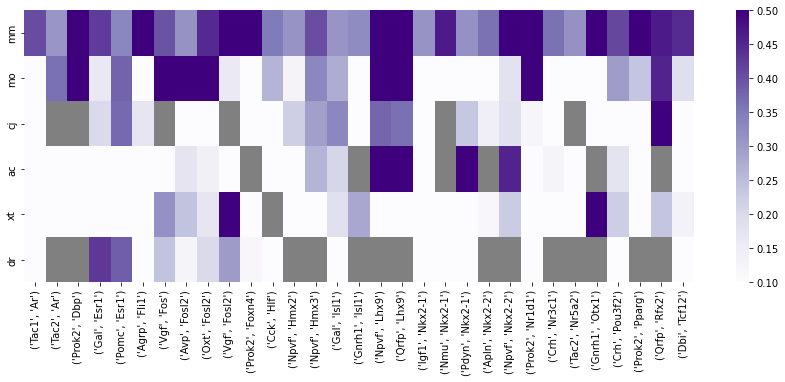

In [54]:
plt.figure(figsize =(15,5))

cmap = mpl.cm.get_cmap("Purples").copy()
cmap.set_bad('grey')  # sets NaN color

sns.heatmap(df_swapped, cmap = cmap, vmax = .5, vmin = 0.1)
plt.savefig('../../Figures/Figures_08022026/NP_TF_relationship_08032026.svg',bbox_inches = 'tight')
plt.savefig('../../Figures/Figures_08022026/NP_TF_relationship_08032026.pdf',bbox_inches = 'tight')